In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from typing import Dict, List, Tuple
import joblib

import torch
from torch. utils.data import DataLoader
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings('ignore')

def set_seed(seed:  int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [11]:
# =============================================================================
# 1. HYBRID CONFIGURATION
# =============================================================================
class HybridTFTConfig:
    def __init__(
        self,
        train_path: str,
        val_path: str,
        test_path: str,
        modflow_path: str,  # Path to MODFLOW predictions CSV
        scaler_path: str = None,
        model_dir: str = 'models/hybrid_tft',
        target_col: str = 'water_level',
        date_col: str = 'date',
        # MODFLOW column names (matching your CSV structure)
        modflow_date_col: str = 'date',
        modflow_pred_col: str = 'simulated_depth_ft',  # The MODFLOW prediction column
        # IMPROVED:  Even longer encoder for better long-term patterns
        max_encoder_length: int = 90,
        max_prediction_length: int = 1,
        hidden_size: int = 128,
        attention_head_size: int = 4,
        lstm_layers: int = 3,
        dropout: float = 0.4,
        hidden_continuous_size: int = 64,
        learning_rate: float = 0.0001,
        batch_size: int = 16,  # Smaller batch for better gradient estimates
        max_epochs: int = 300,
        patience: int = 60,  # Much more patience
        gradient_clip:  float = 0.1,
        # NEW: Weight decay for regularization
        weight_decay: float = 0.1,
        
        # IMPROVED:  Longer encoder for better context
        # max_encoder_length: int = 60,
        # max_prediction_length: int = 1,
        # hidden_size: int = 64,
        # attention_head_size: int = 4,
        # lstm_layers: int = 3,
        # dropout: float = 0.3,
        # hidden_continuous_size: int = 32,
        # learning_rate: float = 0.0003,
        # batch_size: int = 32,  # Smaller batch for better generalization
        # max_epochs: int = 200,
        # patience: int = 30,  # More patience
        # gradient_clip: float = 0.1,
    ):
        self.train_path = train_path
        self. val_path = val_path
        self.test_path = test_path
        self.modflow_path = modflow_path
        self.scaler_path = scaler_path
        self. model_dir = model_dir
        self.target_col = target_col
        self.date_col = date_col
        self.modflow_date_col = modflow_date_col
        self.modflow_pred_col = modflow_pred_col
        self.max_encoder_length = max_encoder_length
        self.max_prediction_length = max_prediction_length
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        self.lstm_layers = lstm_layers
        self.dropout = dropout
        self.hidden_continuous_size = hidden_continuous_size
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.gradient_clip = gradient_clip
        self.weight_decay = weight_decay
        self.use_gpu = torch.cuda.is_available()
        self.device = torch.device('cuda' if self.use_gpu else 'cpu')
        
        os.makedirs(model_dir, exist_ok=True)

In [12]:
# =============================================================================
# 2. HYBRID DATA PREPARATION
# =============================================================================
class HybridDataPreparator:
    """
    Hybrid TFT-MODFLOW Data Preparator
    
    Key features:
    1. Loads MODFLOW monthly predictions and interpolates to daily
    2. Scales MODFLOW predictions to match the target variable scale
    3. Uses MODFLOW predictions as a key input feature (physics prior)
    4. Adds lag features and temporal features
    """
    
    def __init__(self, config: HybridTFTConfig):
        self.config = config
        self.train_df = None
        self.val_df = None
        self.test_df = None
        self. modflow_df = None
        self.full_df = None
        self. target_scaler = None
        self.time_varying_known_cols = []
        self.time_varying_unknown_cols = []
        self.train_cutoff = None
        self.val_cutoff = None
        
    def load_data(self):
        """Load all datasets including MODFLOW predictions."""
        print("=" * 70)
        print("     LOADING DATA (HYBRID)")
        print("=" * 70)
        
        # Load train/val/test data
        self. train_df = pd.read_csv(self.config.train_path)
        self.val_df = pd.read_csv(self.config.val_path)
        self.test_df = pd.read_csv(self. config.test_path)
        
        # Convert dates
        for df in [self.train_df, self.val_df, self. test_df]:
            if self.config.date_col in df.columns:
                df[self.config.date_col] = pd.to_datetime(df[self.config.date_col])
        
        print(f"\n  Train:  {len(self.train_df)} | Val: {len(self.val_df)} | Test: {len(self.test_df)}")
        
        # Load MODFLOW predictions
        if os.path.exists(self.config.modflow_path):
            self.modflow_df = pd.read_csv(self.config.modflow_path)
            if self.config.modflow_date_col in self.modflow_df.columns:
                self. modflow_df[self.config.modflow_date_col] = pd.to_datetime(
                    self.modflow_df[self.config.modflow_date_col]
                )
            print(f"  ✓ Loaded MODFLOW predictions: {len(self.modflow_df)} records")
            print(f"    Columns: {list(self.modflow_df. columns)}")
        else:
            print(f"  ⚠ MODFLOW file not found: {self.config. modflow_path}")
            self.modflow_df = None
        
        # Load scalers
        if self.config.scaler_path and os.path.exists(self. config.scaler_path):
            scalers = joblib.load(self.config.scaler_path)
            self.target_scaler = scalers. get('target_scaler')
            print("  ✓ Loaded scalers")
        
        self._check_distribution()
        
        return self.train_df, self. val_df, self.test_df
    
    def _check_distribution(self):
        """Check distribution shift between splits."""
        target = self.config.target_col
        
        train_mean = self.train_df[target].mean()
        train_std = self.train_df[target].std()
        val_mean = self.val_df[target].mean()
        test_mean = self.test_df[target].mean()
        
        print(f"\n  Distribution Check:")
        print(f"    Train:  mean={train_mean:.4f}, std={train_std:.4f}")
        print(f"    Val:    mean={val_mean:.4f}")
        print(f"    Test:  mean={test_mean:.4f}")
        
        if abs(test_mean - train_mean) > 1.5 * train_std:
            print(f"\n  ⚠ WARNING:  Significant distribution shift detected!")
            print(f"    MODFLOW physics prior will help the model adapt.")
    
    def _interpolate_modflow_to_daily(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Interpolate monthly MODFLOW predictions to daily resolution. 
        This is critical for the hybrid approach as MODFLOW outputs monthly data.
        """
        if self.modflow_df is None:
            return df
        
        print("\n  Interpolating MODFLOW predictions to daily resolution...")
        
        # Get the MODFLOW prediction column
        modflow_col = self.config.modflow_pred_col
        date_col = self.config.modflow_date_col
        
        if modflow_col not in self.modflow_df.columns:
            # Try to find a suitable column
            potential_cols = ['simulated_depth_ft', 'modflow_prediction', 'predicted', 'simulated']
            for col in potential_cols:
                if col in self. modflow_df.columns:
                    modflow_col = col
                    break
            else:
                print(f"    ⚠ Could not find MODFLOW prediction column.  Available:  {list(self.modflow_df.columns)}")
                return df
        
        print(f"    Using MODFLOW column: {modflow_col}")
        
        # Create a copy of MODFLOW data with only needed columns
        modflow_subset = self.modflow_df[[date_col, modflow_col]].copy()
        modflow_subset = modflow_subset.rename(columns={
            date_col: 'date',
            modflow_col: 'modflow_prediction'
        })
        
        # Create daily date range
        date_min = df[self.config.date_col].min()
        date_max = df[self.config.date_col].max()
        daily_dates = pd.date_range(start=date_min, end=date_max, freq='D')
        
        # Create daily dataframe
        daily_df = pd.DataFrame({'date': daily_dates})
        
        # Merge MODFLOW monthly predictions
        daily_df = daily_df.merge(modflow_subset, on='date', how='left')
        
        # Interpolate to fill daily values
        daily_df['modflow_prediction'] = daily_df['modflow_prediction'].interpolate(
            method='linear', 
            limit_direction='both'
        )
        
        # Forward/backward fill any remaining NaN
        daily_df['modflow_prediction'] = daily_df['modflow_prediction'].ffill().bfill()
        
        # Merge with main dataframe
        df = df.merge(daily_df, left_on=self.config.date_col, right_on='date', how='left')
        
        # Handle potential duplicate date column
        if 'date_x' in df.columns:
            df = df.drop(columns=['date_y'])
            df = df.rename(columns={'date_x': self.config.date_col})
        elif 'date' in df.columns and self.config.date_col != 'date':
            df = df.drop(columns=['date'])
        
        # Fill any remaining NaN in modflow_prediction
        if 'modflow_prediction' in df.columns:
            df['modflow_prediction'] = df['modflow_prediction'].interpolate(
                method='linear', limit_direction='both'
            ).ffill().bfill()
            
            # If still NaN (edge case), use target mean
            if df['modflow_prediction'].isna().any():
                df['modflow_prediction'] = df['modflow_prediction'].fillna(
                    df[self.config.target_col].mean()
                )
        
        print(f"    ✓ MODFLOW predictions merged:  {df['modflow_prediction'].notna().sum()} records")
        
        return df
    
    def _scale_modflow_predictions(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Scale MODFLOW predictions to match the target variable scale.
        This is important because MODFLOW outputs are in different units/scale.

        LEAKAGE FIX: the scaling statistics (mean/std of target and of the
        MODFLOW prediction) are computed from the TRAIN split only. Using
        df[target].mean()/.std() over the full (train+val+test) frame would
        let validation/test-period statistics leak into a transform that is
        then applied to the training data itself.
        """
        if 'modflow_prediction' not in df.columns:
            return df
        
        print("\n  Scaling MODFLOW predictions to match target scale...")
        
        target = self.config.target_col
        modflow = 'modflow_prediction'
        
        # Calculate scaling parameters from the TRAIN split only
        if 'split' in df.columns and (df['split'] == 'train').any():
            train_mask = df['split'] == 'train'
        else:
            # Fallback (should not happen in prepare_for_tft's call order)
            train_mask = pd.Series(True, index=df.index)
        
        target_mean = df.loc[train_mask, target].mean()
        target_std = df.loc[train_mask, target].std()
        modflow_mean = df.loc[train_mask, modflow].mean()
        modflow_std = df.loc[train_mask, modflow].std()
        
        # Z-score normalize (using train stats) then rescale to match target distribution
        if modflow_std > 0:
            df['modflow_scaled'] = (df[modflow] - modflow_mean) / modflow_std
            df['modflow_scaled'] = df['modflow_scaled'] * target_std + target_mean
        else:
            df['modflow_scaled'] = df[modflow]
        
        print(f"    Target (train-only):  mean={target_mean:.4f}, std={target_std:.4f}")
        print(f"    MODFLOW (train-only, original): mean={modflow_mean:.4f}, std={modflow_std:.4f}")
        print(f"    MODFLOW (scaled): mean={df['modflow_scaled'].mean():.4f}, std={df['modflow_scaled'].std():.4f}")
        
        return df
    
    def prepare_for_tft(self):
        """Prepare hybrid data with MODFLOW predictions and feature engineering."""
        print("\n" + "=" * 70)
        print("     PREPARING DATA FOR HYBRID TFT")
        print("=" * 70)
        
        if self.train_df is None: 
            self.load_data()
        
        # Add split labels
        self.train_df = self.train_df.copy()
        self.val_df = self.val_df.copy()
        self.test_df = self.test_df.copy()
        
        self.train_df['split'] = 'train'
        self.val_df['split'] = 'val'
        self.test_df['split'] = 'test'
        
        # Combine and sort
        self.full_df = pd.concat([self.train_df, self.val_df, self.test_df], ignore_index=True)
        
        if self.config.date_col in self.full_df.columns:
            self.full_df = self.full_df.sort_values(self.config.date_col).reset_index(drop=True)
        
        # Add time index and group
        self.full_df['time_idx'] = np.arange(len(self. full_df))
        self.full_df['group_id'] = 'well_1'
        
        # Store cutoff indices
        self.train_cutoff = self.full_df[self.full_df['split'] == 'train']['time_idx'].max()
        self.val_cutoff = self.full_df[self.full_df['split'] == 'val']['time_idx'].max()
        
        # CRITICAL: Merge MODFLOW predictions (physics prior)
        self.full_df = self._interpolate_modflow_to_daily(self.full_df)
        
        # Scale MODFLOW predictions to match target (train-split statistics only)
        self.full_df = self._scale_modflow_predictions(self.full_df)
        
        # Add lag features
        self._add_lag_features()
        
        # Add date features
        self._add_date_features()
        
        # Identify features (including MODFLOW as key feature)
        self._identify_features()
        
        # Clean data
        self._clean_data()
        
        print(f"\n  Total records: {len(self.full_df)}")
        print(f"  Train cutoff idx: {self.train_cutoff}")
        print(f"  Val cutoff idx: {self. val_cutoff}")
        
        return self.full_df
    
    def _add_lag_features(self):
        """
        Add lag features including MODFLOW-based features.

        LEAKAGE FIX: the target's rolling mean and first difference used to
        be computed directly on self.full_df[target], so at row t they
        included water_level[t] itself (pandas .rolling(min_periods=1) and
        .diff() both incorporate the current row). Since this is a 1-day
        forecast horizon, that is the target leaking into its own feature.
        Both are now computed on the lag-1 series, so at row t they only
        encode information available through t-1.
        The MODFLOW-target residual is still computed contemporaneously
        (it needs today's observation to know today's MODFLOW error), but
        only its lag-1 version (modflow_residual_lag_1) is ever exposed as
        a model feature -- see _identify_features, where the raw
        'modflow_residual' column is explicitly excluded.
        """
        print("\n  Adding lag features...")
        target = self.config.target_col
        
        # Target lags (already strictly historical: shift(lag), lag >= 1)
        for lag in [1, 7, 14]: 
            self.full_df[f'{target}_lag_{lag}'] = self.full_df[target]. shift(lag)
        
        # Rolling statistics - computed on the lag-1 series so the window
        # at row t covers [t-window, t-1], never t itself
        target_shifted = self.full_df[target].shift(1)
        for window in [7, 14]: 
            self.full_df[f'{target}_rmean_{window}'] = (
                target_shifted.rolling(window=window, min_periods=1).mean()
            )
        
        # First difference (t-1 vs t-2, strictly historical)
        self.full_df[f'{target}_diff'] = target_shifted.diff(1)
        
        # MODFLOW-specific features (if available)
        if 'modflow_scaled' in self.full_df. columns:
            # MODFLOW lags
            for lag in [1, 7]: 
                self.full_df[f'modflow_lag_{lag}'] = self.full_df['modflow_scaled'].shift(lag)
            
            # MODFLOW rolling mean
            self.full_df['modflow_rmean_7'] = (
                self.full_df['modflow_scaled'].rolling(window=7, min_periods=1).mean()
            )
            
            # MODFLOW-target residual (TFT learns to correct MODFLOW errors).
            # Computed contemporaneously (needs today's target) - NOT used
            # directly as a feature, see exclude set in _identify_features.
            self.full_df['modflow_residual'] = self.full_df[target] - self.full_df['modflow_scaled']
            
            # Lagged residual (helps model learn error patterns) - this is
            # the only residual-derived column ever used as a model input,
            # and it only carries information through t-1.
            self.full_df['modflow_residual_lag_1'] = self.full_df['modflow_residual'].shift(1)
        
        print(f"    Added target lags and rolling stats")
        if 'modflow_scaled' in self.full_df.columns:
            print(f"    Added MODFLOW features (key physics prior)")
    
    def _add_date_features(self):
        """Add cyclical date features."""
        if self.config.date_col in self.full_df.columns:
            dates = pd.to_datetime(self.full_df[self.config.date_col])
            
            self.full_df['month_sin'] = np.sin(2 * np.pi * dates.dt.month / 12)
            self.full_df['month_cos'] = np.cos(2 * np.pi * dates.dt. month / 12)
            self.full_df['doy_sin'] = np.sin(2 * np.pi * dates. dt.dayofyear / 365)
            self.full_df['doy_cos'] = np.cos(2 * np.pi * dates.dt.dayofyear / 365)
    
    def _identify_features(self):
        """
        Identify feature types with MODFLOW as key feature.

        NOTE ON LEAKAGE: 'modflow_prediction' (unscaled) and 'modflow_residual'
        (the contemporaneous, un-lagged residual = target - modflow_scaled)
        are deliberately kept in `exclude` and never enter
        time_varying_unknown_cols. Only their lag-safe counterparts
        ('modflow_scaled' and 'modflow_residual_lag_1') are used as inputs.
        time_varying_unknown_cols (plus the target) are only ever sampled
        by TimeSeriesDataSet from encoder (historical) positions, never at
        the decoder/forecast-origin time step, so even the target column
        itself does not leak into its own 1-day-ahead prediction.
        """
        print("\n  Identifying features...")
        
        exclude = {self.config.date_col, 'time_idx', 'group_id', 'split',
                   self.config.target_col, 'Unnamed: 0', 'index', 
                   'modflow_prediction', 'modflow_residual'}
        
        # Known features (calendar - known in future)
        self.time_varying_known_cols = ['month_sin', 'month_cos', 'doy_sin', 'doy_cos']
        self.time_varying_known_cols = [c for c in self.time_varying_known_cols 
                                        if c in self.full_df.columns]
        
        # Unknown features - MODFLOW as priority (key physics feature)
        target = self.config.target_col
        priority_features = [
            # MODFLOW features (CRITICAL - physics prior)
            'modflow_scaled',  # Main MODFLOW prediction
            'modflow_lag_1', 'modflow_lag_7',
            'modflow_rmean_7',
            'modflow_residual_lag_1',  # Helps learn error patterns
            # Target lag features
            f'{target}_lag_1', f'{target}_lag_7', f'{target}_lag_14',
            f'{target}_rmean_7', f'{target}_rmean_14', f'{target}_diff',
            # Climate features (if available)
            'total_precipitation_sum', 'evaporation_sum',
            '2m_temperature_mean', 'surface_pressure_mean',
        ]
        
        numeric_cols = self.full_df.select_dtypes(include=[np.number]).columns. tolist()
        self.time_varying_unknown_cols = [c for c in priority_features 
                                          if c in numeric_cols and c not in exclude]
        
        # Limit features
        max_features = 20
        self.time_varying_unknown_cols = self.time_varying_unknown_cols[:max_features]
        
        print(f"    Known features: {len(self.time_varying_known_cols)}")
        print(f"    Unknown features: {len(self.time_varying_unknown_cols)}")
        print(f"    Feature list:")
        for c in self.time_varying_unknown_cols:
            print(f"      - {c}")
    
    def _clean_data(self):
        """Clean numeric data."""
        all_cols = (self.time_varying_known_cols + 
                   self.time_varying_unknown_cols + 
                   [self.config.target_col])
        
        for col in all_cols:
            if col in self.full_df.columns:
                self.full_df[col] = pd.to_numeric(self.full_df[col], errors='coerce')
                self.full_df[col] = self.full_df[col]. replace([np.inf, -np.inf], np.nan)
                self.full_df[col] = self.full_df[col].interpolate(method='linear', limit_direction='both')
                self.full_df[col] = self.full_df[col].ffill().bfill().fillna(0)
    
    def create_datasets(self):
        """Create TFT datasets."""
        print("\n" + "=" * 70)
        print("     CREATING DATASETS (HYBRID)")
        print("=" * 70)
        
        if self.full_df is None:
            self.prepare_for_tft()
        
        cfg = self.config
        
        # Skip rows with NaN lags
        min_valid_idx = max(cfg.max_encoder_length, 14)
        
        print(f"\n  Encoder length: {cfg.max_encoder_length}")
        print(f"  Prediction length: {cfg.max_prediction_length}")
        print(f"  Min valid idx: {min_valid_idx}")
        print(f"  Train cutoff: {self.train_cutoff}")
        print(f"  Val cutoff: {self.val_cutoff}")
        
        # Training data
        train_data = self. full_df[
            (self.full_df['time_idx'] >= min_valid_idx) & 
            (self.full_df['time_idx'] <= self.train_cutoff - cfg.max_prediction_length)
        ].copy()
        
        print(f"\n  Training data points: {len(train_data)}")
        
        if len(train_data) < cfg.max_encoder_length + 10:
            print("  ⚠ Not enough training data!  Adjusting encoder length...")
            cfg.max_encoder_length = max(10, len(train_data) // 3)
            print(f"  New encoder length: {cfg.max_encoder_length}")
        
        # Create training TimeSeriesDataSet
        training = TimeSeriesDataSet(
            train_data,
            time_idx='time_idx',
            target=cfg.target_col,
            group_ids=['group_id'],
            min_encoder_length=cfg.max_encoder_length // 2,
            max_encoder_length=cfg.max_encoder_length,
            min_prediction_length=1,
            max_prediction_length=cfg.max_prediction_length,
            static_categoricals=['group_id'],
            time_varying_known_reals=self.time_varying_known_cols,
            time_varying_unknown_reals=self.time_varying_unknown_cols + [cfg.target_col],
            target_normalizer=None,
            add_relative_time_idx=True,
            add_target_scales=True,
            add_encoder_length=True,
            allow_missing_timesteps=True,
        )
        
        print(f"\n  Training dataset samples: {len(training)}")
        
        # Validation data
        train_val_data = self.full_df[
            (self.full_df['time_idx'] >= min_valid_idx) & 
            (self.full_df['time_idx'] <= self.val_cutoff)
        ].copy()
        
        validation = TimeSeriesDataSet. from_dataset(
            training,
            train_val_data,
            predict=False,
            stop_randomization=True,
        )
        
        print(f"  Validation dataset samples: {len(validation)}")
        
        # Test data
        all_valid_data = self.full_df[self.full_df['time_idx'] >= min_valid_idx].copy()
        
        testing = TimeSeriesDataSet.from_dataset(
            training,
            all_valid_data,
            predict=False,
            stop_randomization=True,
        )
        
        print(f"  Test dataset samples: {len(testing)}")
        
        # Dataloaders
        train_loader = training.to_dataloader(
            train=True, 
            batch_size=cfg. batch_size, 
            num_workers=0,
            shuffle=True
        )
        val_loader = validation.to_dataloader(
            train=False, 
            batch_size=cfg.batch_size * 2, 
            num_workers=0
        )
        test_loader = testing.to_dataloader(
            train=False, 
            batch_size=cfg.batch_size * 2, 
            num_workers=0
        )
        
        print(f"\n  Train batches: {len(train_loader)}")
        print(f"  Val batches: {len(val_loader)}")
        print(f"  Test batches:  {len(test_loader)}")
        
        return training, validation, testing, train_loader, val_loader, test_loader
    
    def inverse_transform(self, scaled_values):
        """Inverse transform predictions."""
        if self.target_scaler is not None:
            if len(scaled_values. shape) == 1:
                scaled_values = scaled_values. reshape(-1, 1)
            return self.target_scaler.inverse_transform(scaled_values).flatten()
        return scaled_values

In [13]:
# =============================================================================
# 3. TRAINING
# =============================================================================
def get_prediction_tensor(output):
    """Extract prediction tensor from TFT output."""
    if isinstance(output, dict):
        return output['prediction']
    if hasattr(output, 'prediction'):
        return output.prediction
    if isinstance(output, torch.Tensor):
        return output
    return output


def train_hybrid_tft(
    model: TemporalFusionTransformer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    config,  # HybridTFTConfig
) -> Tuple[TemporalFusionTransformer, List[float], List[float]]:
    """
    Improved training loop for hybrid TFT-MODFLOW model.
    
    Key improvements:
    1. Better regularization with label smoothing and mixup-style augmentation
    2. Warmup learning rate schedule
    3. Gradient accumulation for effective larger batch sizes
    4. Multiple loss functions combined
    5. Better early stopping with minimum epochs
    """
    print("\n" + "=" * 70)
    print("     TRAINING HYBRID TFT-MODFLOW MODEL (IMPROVED)")
    print("=" * 70)
    
    device = config.device
    model = model.to(device)
    
    # Optimizer with different learning rates for different parameter groups
    # Lower LR for pretrained-style layers, higher for task-specific
    optimizer = torch.optim. AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=0.1,  # Increased weight decay for regularization
        betas=(0.9, 0.999),
        eps=1e-8,
    )
    
    # Warmup + Cosine Annealing scheduler
    warmup_epochs = min(10, config.max_epochs // 10)
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup
            return (epoch + 1) / warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - warmup_epochs) / (config.max_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Multiple loss functions
    mse_loss = torch.nn.MSELoss()
    mae_loss = torch.nn.L1Loss()
    huber_loss = torch.nn. SmoothL1Loss(beta=0.5)  # Robust to outliers
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    
    # Minimum epochs before early stopping can trigger
    min_epochs = max(20, config.max_epochs // 5)
    
    # Gradient accumulation steps (effective batch size = batch_size * accumulation_steps)
    accumulation_steps = 2
    
    print(f"\n  Device: {device}")
    print(f"  Max epochs: {config.max_epochs}")
    print(f"  Min epochs before early stopping: {min_epochs}")
    print(f"  Patience:  {config.patience}")
    print(f"  Learning rate: {config.learning_rate}")
    print(f"  Warmup epochs: {warmup_epochs}")
    print(f"  Gradient accumulation steps: {accumulation_steps}")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    
    for epoch in range(config.max_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        n_train = 0
        
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(train_loader):
            x, y = batch
            
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            
            if isinstance(y, (tuple, list)):
                target = y[0]. to(device)
            else:
                target = y.to(device)
            
            # Forward pass
            output = model(x)
            prediction = get_prediction_tensor(output)
            
            if not isinstance(prediction, torch.Tensor):
                continue
            
            # Extract median prediction
            if len(prediction.shape) == 3:
                pred_median = prediction[: , : , prediction.shape[2] // 2]
            else:
                pred_median = prediction
            
            # Handle shape mismatch
            if pred_median.shape != target.shape:
                if len(pred_median.shape) == 2 and len(target.shape) == 2:
                    min_len = min(pred_median.shape[1], target.shape[1])
                    pred_median = pred_median[:, :min_len]
                    target = target[:, :min_len]
            
            # Combined loss with emphasis on robustness
            # MSE for accuracy, MAE for robustness, Huber for balance
            loss_mse = mse_loss(pred_median, target)
            loss_mae = mae_loss(pred_median, target)
            loss_huber = huber_loss(pred_median, target)
            
            # Weighted combination - emphasize Huber for robustness
            loss = 0.3 * loss_mse + 0.3 * loss_mae + 0.4 * loss_huber
            
            # Add temporal consistency regularization
            if pred_median.shape[0] > 1:
                # Penalize large differences between consecutive predictions
                pred_diff = torch.diff(pred_median, dim=0)
                target_diff = torch.diff(target, dim=0)
                consistency_loss = mae_loss(pred_diff, target_diff)
                loss = loss + 0.1 * consistency_loss
            
            # Scale loss for gradient accumulation
            loss = loss / accumulation_steps
            loss.backward()
            
            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
                optimizer.step()
                optimizer.zero_grad()
            
            epoch_train_loss += loss.item() * accumulation_steps
            n_train += 1
        
        scheduler.step()
        
        avg_train_loss = epoch_train_loss / max(n_train, 1)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0
        n_val = 0
        val_predictions = []
        val_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                
                x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
                
                if isinstance(y, (tuple, list)):
                    target = y[0].to(device)
                else: 
                    target = y.to(device)
                
                output = model(x)
                prediction = get_prediction_tensor(output)
                
                if not isinstance(prediction, torch.Tensor):
                    continue
                
                if len(prediction.shape) == 3:
                    pred_median = prediction[:, :, prediction. shape[2] // 2]
                else:
                    pred_median = prediction
                
                if pred_median.shape != target.shape:
                    if len(pred_median.shape) == 2 and len(target. shape) == 2:
                        min_len = min(pred_median.shape[1], target.shape[1])
                        pred_median = pred_median[: , :min_len]
                        target = target[:, :min_len]
                
                # Use same combined loss for validation
                loss_mse = mse_loss(pred_median, target)
                loss_mae = mae_loss(pred_median, target)
                loss_huber = huber_loss(pred_median, target)
                loss = 0.3 * loss_mse + 0.3 * loss_mae + 0.4 * loss_huber
                
                epoch_val_loss += loss.item()
                n_val += 1
                
                val_predictions. append(pred_median.cpu())
                val_targets.append(target.cpu())
        
        avg_val_loss = epoch_val_loss / max(n_val, 1)
        val_losses.append(avg_val_loss)
        
        # Calculate additional metrics for monitoring
        if val_predictions:
            all_preds = torch.cat(val_predictions, dim=0).numpy().flatten()
            all_targets = torch.cat(val_targets, dim=0).numpy().flatten()
            val_rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
        else:
            val_rmse = float('inf')
        
        # Current learning rate
        current_lr = scheduler.get_last_lr()[0]
        
        # Logging
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config.max_epochs}:   "
                  f"Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}, "
                  f"Val_RMSE={val_rmse:.4f}, LR={current_lr:.6f}")
        
        # Early stopping logic (only after min_epochs)
        if epoch >= min_epochs - 1:
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                print(f"  Epoch {epoch+1:3d}:  ✓ New best = {avg_val_loss:.4f} (RMSE={val_rmse:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= config.patience:
                    print(f"\n  Early stopping at epoch {epoch+1}")
                    break
        elif avg_val_loss < best_val_loss:
            # Still track best model during warmup period
            best_val_loss = avg_val_loss
            best_state = {k: v. cpu().clone() for k, v in model.state_dict().items()}
            print(f"  Epoch {epoch+1:3d}:  ✓ New best = {avg_val_loss:.4f} (warmup)")
    
    # Load best model
    if best_state: 
        model.load_state_dict(best_state)
        model = model.to(device)
    
    # Save model
    model_path = os.path.join(config.model_dir, 'hybrid_tft_modflow.pt')
    torch.save(model.state_dict(), model_path)
    print(f"\n  Best model saved:  {model_path}")
    print(f"  Best validation loss: {best_val_loss:.4f}")
    
    return model, train_losses, val_losses


def predict_tft(model, data_loader, device, return_uncertainty=False):
    """
    Make predictions with TFT. 
    
    Improvements:
    1. Option to return uncertainty estimates
    2. Better handling of quantile predictions
    3. More robust index tracking
    """
    model.eval()
    
    all_predictions = []
    all_actuals = []
    all_indices = []
    all_lower = []  # Lower quantile
    all_upper = []  # Upper quantile
    
    with torch.no_grad():
        for batch in data_loader: 
            x, y = batch
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            
            if isinstance(y, (tuple, list)):
                target = y[0].cpu().numpy()
            else:
                target = y.cpu().numpy()
            
            output = model(x)
            prediction = get_prediction_tensor(output)
            
            if isinstance(prediction, torch.Tensor):
                predictions = prediction.cpu().numpy()
            else:
                continue
            
            # Extract indices
            if 'decoder_time_idx' in x:
                indices = x['decoder_time_idx'][: , 0]. cpu().numpy().tolist()
            else:
                indices = list(range(len(predictions)))
            
            all_predictions.append(predictions)
            all_actuals.append(target)
            all_indices.extend(indices)
            
            # Extract uncertainty bounds if available
            if return_uncertainty and len(predictions. shape) == 3 and predictions.shape[2] >= 3:
                # Assuming quantiles are ordered:  lower, median, upper
                all_lower.append(predictions[:, :, 0])  # Lower quantile
                all_upper.append(predictions[:, : , -1])  # Upper quantile
    
    if len(all_predictions) > 0:
        preds = np.concatenate(all_predictions, axis=0)
        actuals = np.concatenate(all_actuals, axis=0)
        
        if return_uncertainty and all_lower:
            lower = np.concatenate(all_lower, axis=0)
            upper = np.concatenate(all_upper, axis=0)
            return preds, actuals, all_indices, lower, upper
        
        return preds, actuals, all_indices
    else: 
        if return_uncertainty:
            return np.array([]), np.array([]), [], np.array([]), np.array([])
        return np.array([]), np.array([]), []

In [14]:
# =============================================================================
# 4. METRICS AND PLOTTING
# =============================================================================
def calculate_metrics(observed:  np.ndarray, predicted: np.ndarray) -> Dict[str, float]:
    """Calculate metrics."""
    if len(predicted.shape) > 1:
        if predicted.shape[-1] >= 7:
            predicted = predicted[..., predicted.shape[-1] // 2]
        elif predicted.shape[-1] > 1:
            predicted = predicted[..., 0]
    
    observed = observed. flatten()
    predicted = predicted. flatten()
    
    n = min(len(observed), len(predicted))
    obs, pred = observed[:n], predicted[: n]
    
    mask = ~(np.isnan(obs) | np.isnan(pred))
    obs, pred = obs[mask], pred[mask]
    
    if len(obs) == 0:
        return {'RMSE': np.nan, 'MAE':  np.nan, 'R2': np.nan, 'NSE': np.nan}
    
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    mae = np.mean(np.abs(pred - obs))
    
    ss_res = np.sum((obs - pred) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': r2}


def plot_training_history(train_losses, val_losses, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, 'b-', label='Training Loss', linewidth=2)
    plt.plot(val_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Hybrid TFT-MODFLOW Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Training plot saved:  {save_path}")
    
    plt.show()


def plot_results(dates, observed, predicted, metrics, title='Hybrid TFT-MODFLOW Results',
                 save_path=None, is_scaled=True):
    if len(predicted.shape) > 1:
        if predicted.shape[-1] >= 7:
            pred = predicted[..., predicted.shape[-1] // 2]
        else:
            pred = predicted[..., 0]
    else:
        pred = predicted
    
    pred = np.array(pred).flatten()
    observed = np.array(observed).flatten()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    n = min(len(dates), len(observed), len(pred))
    dates, observed, pred = dates[:n], observed[:n], pred[:n]
    
    ylabel = 'Water Level (scaled)' if is_scaled else 'Depth to Water (feet)'
    
    # Time series
    ax1 = axes[0, 0]
    ax1.plot(dates, observed, 'b-', label='Observed', linewidth=2)
    ax1.plot(dates, pred, 'r--', label='Hybrid TFT-MODFLOW', linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel(ylabel)
    ax1.set_title('Time Series Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    if not is_scaled:
        ax1.invert_yaxis()
    ax1.tick_params(axis='x', rotation=45)
    
    # Scatter
    ax2 = axes[0, 1]
    ax2.scatter(observed, pred, alpha=0.5, s=30)
    lims = [min(observed. min(), pred.min()), max(observed.max(), pred.max())]
    ax2.plot(lims, lims, 'k--', linewidth=2)
    ax2.set_xlabel('Observed')
    ax2.set_ylabel('Predicted')
    ax2.set_title(f'Scatter Plot (R² = {metrics["R2"]:.3f})')
    ax2.grid(True, alpha=0.3)
    
    # Residuals
    ax3 = axes[1, 0]
    residuals = pred - observed
    ax3.plot(dates, residuals, 'g-', linewidth=1)
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Residual')
    ax3.set_title(f'Residuals (RMSE = {metrics["RMSE"]:.4f})')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residual Distribution')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Results plot saved:  {save_path}")
    
    plt.show()

In [15]:
# =============================================================================
# 5. MAIN PIPELINE
# =============================================================================
def run_hybrid_tft_modflow_pipeline(
    train_path: str,
    val_path: str,
    test_path: str,
    modflow_path: str,
    scaler_path: str = None,
    model_dir: str = 'models/hybrid_tft',
    target_col: str = 'water_level',
    date_col: str = 'date',
    modflow_pred_col: str = 'simulated_depth_ft',
    max_encoder_length: int = 30,
    max_prediction_length: int = 1,
    hidden_size: int = 32,
    attention_head_size: int = 2,
    lstm_layers: int = 2,
    dropout: float = 0.2,
    learning_rate: float = 0.001,
    batch_size: int = 64,
    max_epochs: int = 100,
    patience: int = 15,
):
    """Run the complete Hybrid TFT-MODFLOW pipeline."""
    print("\n" + "█" * 70)
    print("   HYBRID TFT-MODFLOW PIPELINE")
    print("   Physics-Informed Deep Learning for Groundwater Prediction")
    print("█" * 70)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n  Device: {device}")
    if torch.cuda.is_available():
        print(f"  GPU:  {torch.cuda.get_device_name(0)}")
    
    config = HybridTFTConfig(
        train_path=train_path,
        val_path=val_path,
        test_path=test_path,
        modflow_path=modflow_path,
        scaler_path=scaler_path,
        model_dir=model_dir,
        target_col=target_col,
        date_col=date_col,
        modflow_pred_col=modflow_pred_col,
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        lstm_layers=lstm_layers,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        max_epochs=max_epochs,
        patience=patience,
    )
    
    # Step 1: Prepare Data
    data_prep = HybridDataPreparator(config)
    data_prep.load_data()
    data_prep.prepare_for_tft()
    
    training, validation, testing, train_loader, val_loader, test_loader = data_prep.create_datasets()
    
    if len(training) < 50:
        print("\n  ⚠ Not enough training samples!")
        return None, None, None, None
    
    # Step 2: Build Model
    print("\n" + "=" * 70)
    print("     BUILDING HYBRID TFT-MODFLOW MODEL")
    print("=" * 70)
    
    model = TemporalFusionTransformer. from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=config.hidden_continuous_size,
        lstm_layers=lstm_layers,
        output_size=7,
        loss=QuantileLoss(),
        log_interval=10,
        reduce_on_plateau_patience=5,
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n  Model parameters: {total_params:,}")
    
    # Step 3: Train
    model, train_losses, val_losses = train_hybrid_tft(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
    )
    
    plot_training_history(
        train_losses, val_losses,
        save_path=os.path.join(model_dir, 'hybrid_training_history.png')
    )
    
    # Step 4: Evaluate
    print("\n" + "=" * 70)
    print("     EVALUATION")
    print("=" * 70)
    
    # Validation
    print("\n  Evaluating on validation set...")
    val_preds, val_actuals, val_indices = predict_tft(model, val_loader, device)
    
    # Test
    print("  Evaluating on test set...")
    test_preds, test_actuals, test_indices = predict_tft(model, test_loader, device)
    
    # Process predictions
    def process_preds(preds, actuals):
        if len(preds. shape) == 3:
            preds = preds[: , 0, preds.shape[2] // 2]
        elif len(preds.shape) == 2 and preds.shape[1] >= 7:
            preds = preds[:, preds.shape[1] // 2]
        elif len(preds.shape) == 2: 
            preds = preds[: , 0]
        
        if len(actuals.shape) == 2:
            actuals = actuals[:, 0]
        
        return preds. flatten(), actuals.flatten()
    
    # Metrics
    if len(val_preds) > 0:
        val_p, val_a = process_preds(val_preds, val_actuals)
        val_metrics = calculate_metrics(val_a, val_p)
        
        print("\n  Validation Metrics:")
        print("  " + "-" * 40)
        for k, v in val_metrics.items():
            print(f"    {k}: {v:.4f}")
    
    if len(test_preds) > 0:
        test_p, test_a = process_preds(test_preds, test_actuals)
        test_metrics = calculate_metrics(test_a, test_p)
        
        print("\n  Test Metrics:")
        print("  " + "-" * 40)
        for k, v in test_metrics.items():
            print(f"    {k}: {v:.4f}")
        
        # Get dates for plotting
        df = data_prep.full_df
        test_dates = []
        for idx in test_indices[: len(test_p)]:
            row = df[df['time_idx'] == idx]
            if len(row) > 0:
                test_dates.append(row[date_col].values[0])
        test_dates = np.array(test_dates)
        
        # Plot
        if len(test_dates) > 0:
            n = min(len(test_dates), len(test_a), len(test_p))
            plot_results(
                dates=test_dates[:n],
                observed=test_a[:n],
                predicted=test_p[:n],
                metrics=test_metrics,
                title='Hybrid TFT-MODFLOW Groundwater Prediction',
                save_path=os.path.join(model_dir, 'hybrid_results.png'),
                is_scaled=True,
            )
    else:
        test_metrics = {}
    
    # Save
    print("\n  Saving results...")
    if len(test_preds) > 0:
        results_df = pd.DataFrame({
            'time_idx': test_indices[: len(test_p)],
            'observed': test_a,
            'predicted': test_p,
            'residual': test_p - test_a,
        })
        results_df.to_csv(os.path.join(model_dir, 'hybrid_predictions.csv'), index=False)
    
    print(f"\n  ✓ Results saved to:  {model_dir}")
    
    print("\n" + "█" * 70)
    print("   HYBRID TFT-MODFLOW PIPELINE COMPLETE!")
    print("█" * 70)
    
    return test_p if len(test_preds) > 0 else None, test_a if len(test_preds) > 0 else None, test_metrics, model


In [16]:
import pandas as pd
modflow_df = pd.read_csv('models/modflow_enhanced/enhanced_predictions.csv')
print(modflow_df.columns.tolist())

['date', 'observed_depth_ft', 'simulated_depth_ft', 'residual_ft', 'split']



██████████████████████████████████████████████████████████████████████
   HYBRID TFT-MODFLOW PIPELINE
   Physics-Informed Deep Learning for Groundwater Prediction
██████████████████████████████████████████████████████████████████████

  Device: cpu
     LOADING DATA (HYBRID)

  Train:  2464 | Val: 730 | Test: 712
  ✓ Loaded MODFLOW predictions: 132 records
    Columns: ['date', 'observed_depth_ft', 'simulated_depth_ft', 'residual_ft', 'split']
  ✓ Loaded scalers

  Distribution Check:
    Train:  mean=0.0000, std=1.0002
    Val:    mean=1.7960
    Test:  mean=1.9010

  ⚠ WARNING:  Significant distribution shift detected!
    MODFLOW physics prior will help the model adapt.

     PREPARING DATA FOR HYBRID TFT

  Interpolating MODFLOW predictions to daily resolution...
    Using MODFLOW column: simulated_depth_ft
    ✓ MODFLOW predictions merged:  3906 records

  Scaling MODFLOW predictions to match target scale...
    Target (train-only):  mean=0.0000, std=1.0002
    MODFLOW (train-onl

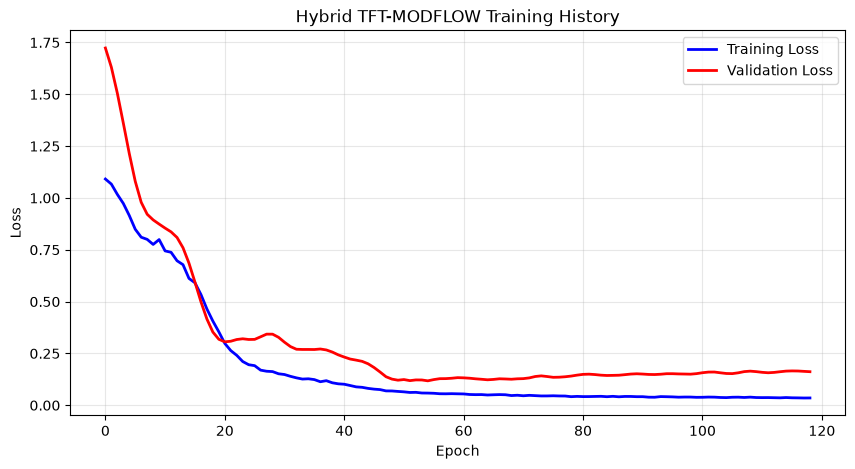


     EVALUATION

  Evaluating on validation set...
  Evaluating on test set...

  Validation Metrics:
  ----------------------------------------
    RMSE: 0.2426
    MAE: 0.1935
    R2: 0.9489
    NSE: 0.9489

  Test Metrics:
  ----------------------------------------
    RMSE: 0.2818
    MAE: 0.2239
    R2: 0.9341
    NSE: 0.9341
  Results plot saved:  models/hybrid_tft\hybrid_results.png


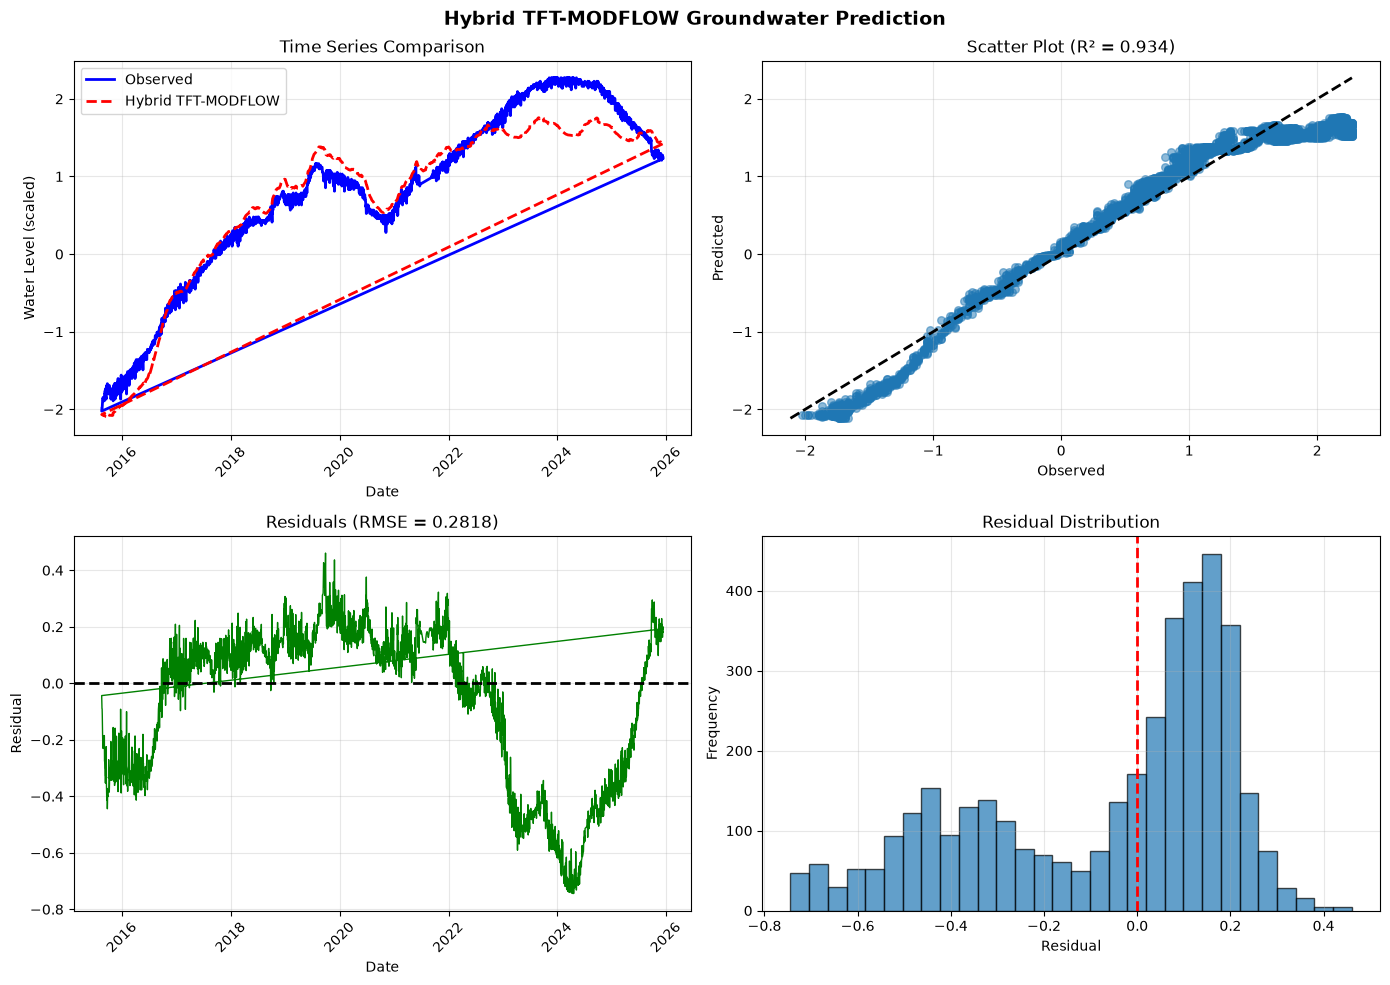


  Saving results...

  ✓ Results saved to:  models/hybrid_tft

██████████████████████████████████████████████████████████████████████
   HYBRID TFT-MODFLOW PIPELINE COMPLETE!
██████████████████████████████████████████████████████████████████████

HYBRID TFT-MODFLOW FINAL RESULTS
  RMSE: 0.2818
  MAE: 0.2239
  R2: 0.9341
  NSE: 0.9341


In [17]:
# =============================================================================
# EXECUTION
# =============================================================================
if __name__ == "__main__": 
    
    predictions, actuals, metrics, model = run_hybrid_tft_modflow_pipeline(
        # Data paths (flat layout: data/ and models/ are siblings of this file)
        train_path='data/processed/train_scaled.csv',
        val_path='data/processed/val_scaled.csv',
        test_path='data/processed/test_scaled.csv',
        modflow_path='models/modflow_enhanced/enhanced_predictions.csv',
        scaler_path='data/processed/scalers.joblib',
        
        # Output
        model_dir='models/hybrid_tft',
        
        # Data columns
        target_col='water_level',
        date_col='date',
        modflow_pred_col='simulated_depth_ft',  # Column name in your MODFLOW CSV
        
        # Model parameters
        max_encoder_length=90,
        max_prediction_length=1,
        hidden_size=128,
        attention_head_size=24,
        lstm_layers=3,
        dropout=0.4,
        learning_rate=0.0001,
        batch_size=616,
        max_epochs=300,
        patience=60,
        # Improved hyperparameters
        # max_encoder_length=60,
        # max_prediction_length=1,
        # hidden_size=64,
        # attention_head_size=4,
        # lstm_layers=3,
        # dropout=0.3,
        # learning_rate=0.0003,
        # batch_size=32,
        # max_epochs=200,
        # patience=30,
    )
    
    if metrics:
        print("\n" + "=" * 50)
        print("HYBRID TFT-MODFLOW FINAL RESULTS")
        print("=" * 50)
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")